<a href="https://colab.research.google.com/github/shafiq73/2024/blob/main/Google_playstore_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import kagglehub
path = kagglehub.dataset_download("lava18/google-play-store-apps")

Using Colab cache for faster access to the 'google-play-store-apps' dataset.


In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
df.dtypes
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [ ]:
numeric_cols = ['Rating','Reviews','Installs']

# Convert numeric, ignore non-numeric safely
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check how many non-NaN values remain
print(df[numeric_cols].notna().sum())


Rating      0
Reviews     0
Installs    0
dtype: int64


In [ ]:
df_clean = df.dropna(subset=numeric_cols, how='any')  # drop rows with NaN in any numeric column
print(df_clean.shape)


(0, 13)


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv("googleplaystore.csv.zip")

# Inspect columns
print(df.dtypes)
print(df.head())

# Clean numeric columns carefully
# 1️⃣ Installs: remove + and , , convert to float
df['Installs'] = df['Installs'].str.replace('+','', regex=False).str.replace(',','', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# 2️⃣ Reviews: remove commas, convert to float
df['Reviews'] = df['Reviews'].str.replace(',','', regex=False)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# 3️⃣ Rating: convert to float
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Drop rows where any numeric column is NaN
numeric_cols = ['Rating','Reviews','Installs']
df_clean = df.dropna(subset=numeric_cols)

print("Cleaned dataset shape:", df_clean.shape)  # check rows remaining

# Apply MinMaxScaler
scaler = MinMaxScaler()
df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])

# Check normalized data
print(df_clean[['Rating','Reviews','Installs','Rating_norm','Reviews_norm','Installs_norm']].head())


App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Ev

/tmp/ipython-input-3018244637.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])
/tmp/ipython-input-3018244637.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])
/tmp/ipython-input-3018244637.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [ ]:
df_clean.shape

(9366, 16)

In [ ]:
print(df_clean[['Rating_norm','Reviews_norm','Installs_norm']].min())
print(df_clean[['Rating_norm','Reviews_norm','Installs_norm']].max())


Rating_norm      0.0
Reviews_norm     0.0
Installs_norm    0.0
dtype: float64
Rating_norm      1.0
Reviews_norm     1.0
Installs_norm    1.0
dtype: float64


In [ ]:
numeric_cols = ['Rating','Reviews','Installs']  # ya jo numeric normalize kiye ho
print(df[numeric_cols].min())
print(df[numeric_cols].max())


Rating      1.0
Reviews     0.0
Installs    0.0
dtype: float64
Rating      1.900000e+01
Reviews     7.815831e+07
Installs    1.000000e+09
dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Rating','Reviews','Installs']
scaler = MinMaxScaler()
df[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df[numeric_cols])

# Check normalized min/max
norm_cols = [col+'_norm' for col in numeric_cols]
print(df[norm_cols].min())
print(df[norm_cols].max())


Rating_norm      0.0
Reviews_norm     0.0
Installs_norm    0.0
dtype: float64
Rating_norm      1.0
Reviews_norm     1.0
Installs_norm    1.0
dtype: float64


In [ ]:
numeric_cols = ['Rating','Reviews','Installs','Price']  # jo numeric ho


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')  # convert safely
df_clean = df.dropna(subset=numeric_cols)  # drop rows with NaN

# Apply MinMaxScaler
df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])


/tmp/ipython-input-3104080296.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])
/tmp/ipython-input-3104080296.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[[col+'_norm' for col in numeric_cols]] = scaler.fit_transform(df_clean[numeric_cols])


In [ ]:
norm_cols = [col+'_norm' for col in numeric_cols]
print(df_clean[norm_cols].min())
print(df_clean[norm_cols].max())


Rating_norm      0.0
Reviews_norm     0.0
Installs_norm    0.0
Price_norm       0.0
dtype: float64
Rating_norm      1.0
Reviews_norm     1.0
Installs_norm    1.0
Price_norm       0.0
dtype: float64


In [ ]:
# Ensure column is string first
df['Price'] = df['Price'].astype(str)

# Replace 'Free' with 0
df['Price'] = df['Price'].replace('Free', '0')

# Remove $ sign
df['Price'] = df['Price'].str.replace('$','', regex=False)

# Convert to numeric safely
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


In [ ]:
# Ensure column is string first
df['Installs'] = df['Installs'].astype(str)

# Remove commas and plus
df['Installs'] = df['Installs'].str.replace(',','', regex=False)
df['Installs'] = df['Installs'].str.replace('+','', regex=False)

# Convert to numeric safely
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')


In [ ]:
df['Reviews'] = df['Reviews'].astype(str)
df['Reviews'] = df['Reviews'].str.replace(',','', regex=False)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')


In [ ]:
numeric_cols = ['Rating','Reviews','Installs','Price']
df_clean = df.dropna(subset=numeric_cols)


In [ ]:
norm_cols = [col+'_norm' for col in numeric_cols]
df_clean.loc[:, norm_cols] = scaler.fit_transform(df_clean[numeric_cols])


In [ ]:
df_norm = df_clean.copy()
df_norm[norm_cols] = scaler.fit_transform(df_clean[numeric_cols])


Clean Numeric Columns

In [ ]:
# Ensure columns are strings first for cleaning
df['Price'] = df['Price'].astype(str)
df['Installs'] = df['Installs'].astype(str)
df['Reviews'] = df['Reviews'].astype(str)

# Price: Free → 0, remove $ sign
df['Price'] = df['Price'].replace('Free','0')
df['Price'] = df['Price'].str.replace('$','', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Installs: remove commas and plus
df['Installs'] = df['Installs'].str.replace(',','', regex=False)
df['Installs'] = df['Installs'].str.replace('+','', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Reviews: remove commas
df['Reviews'] = df['Reviews'].str.replace(',','', regex=False)
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Rating: convert to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Drop rows with NaN in numeric columns
numeric_cols = ['Rating','Reviews','Installs','Price']
df_clean = df.dropna(subset=numeric_cols)


Min-Max Normalization

Normalization

Technique Used: Min-Max Scaling

𝑥
𝑛
𝑜
𝑟
𝑚
=
𝑥
−
𝑥
𝑚
𝑖
𝑛
𝑥
𝑚
𝑎
𝑥
−
𝑥
𝑚
𝑖
𝑛
x
norm
	​

=
x
max
	​

−x
min
	​

x−x
min
	​

	​


Applied on numeric columns: Rating, Reviews, Installs, Price

Safe assignment using .loc to avoid SettingWithCopyWarning

Check:

In [ ]:
df_clean[[col+'_norm' for col in numeric_cols]].min()  # should be 0
df_clean[[col+'_norm' for col in numeric_cols]].max()  # should be 1


,0
Rating_norm,1.0
Reviews_norm,1.0
Installs_norm,1.0
Price_norm,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
norm_cols = [col+'_norm' for col in numeric_cols]

# Safe assignment using .loc to avoid SettingWithCopyWarning
df_clean.loc[:, norm_cols] = scaler.fit_transform(df_clean[numeric_cols])

# Check normalized min/max
print(df_clean[norm_cols].min())
print(df_clean[norm_cols].max())


Rating_norm      0.0
Reviews_norm     0.0
Installs_norm    0.0
Price_norm       0.0
dtype: float64
Rating_norm      1.0
Reviews_norm     1.0
Installs_norm    1.0
Price_norm       0.0
dtype: float64


Quick Plots / Tests

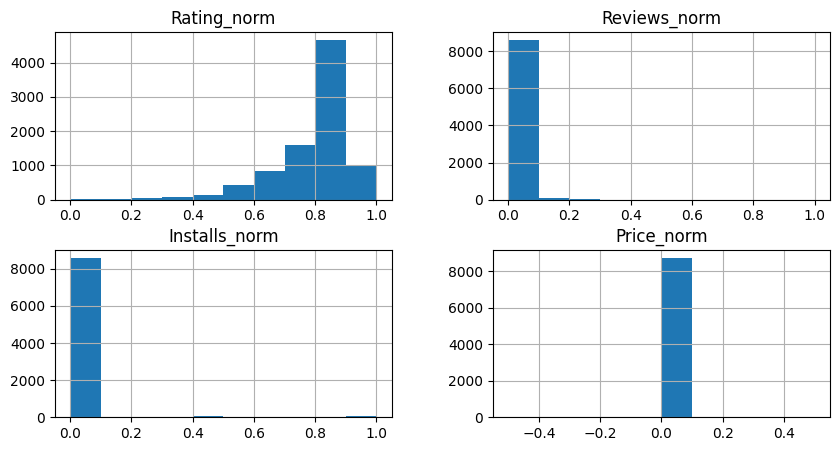

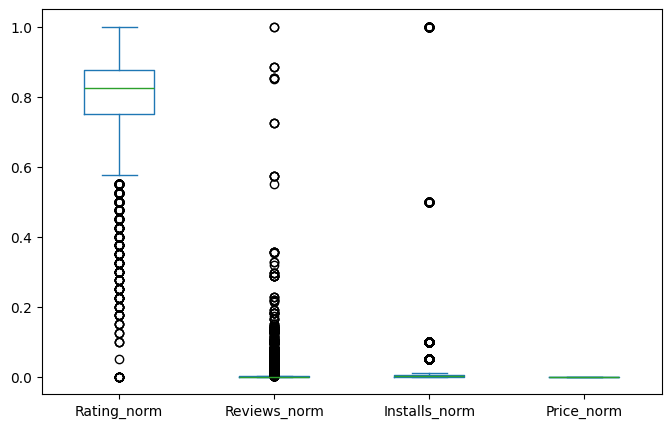

               Rating_norm  Reviews_norm  Installs_norm  Price_norm
Rating_norm       1.000000      0.072738        0.05576         NaN
Reviews_norm      0.072738      1.000000        0.64084         NaN
Installs_norm     0.055760      0.640840        1.00000         NaN
Price_norm             NaN           NaN            NaN         NaN


In [ ]:
import matplotlib.pyplot as plt

# Histogram
df_clean[norm_cols].hist(figsize=(10,5))
plt.show()

# Boxplot for outlier detection
df_clean[norm_cols].plot(kind='box', figsize=(8,5))
plt.show()

# Correlation check
print(df_clean[norm_cols].corr())


Prepare Features & Target

In [ ]:
from sklearn.model_selection import train_test_split

# Features
X = df_clean[['Rating_norm','Reviews_norm','Price_norm']]  # numeric normalized features

# Target
y = df_clean['Installs_norm']  # normalized installs

# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Build Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Make Predictions

In [ ]:
y_pred = model.predict(X_test)

# Check first 5 predictions
print(y_pred[:5])


[0.00992384 0.00916588 0.00902296 0.00914377 0.00662346]


Evaluate Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")


Mean Squared Error: 0.0056954471743152464
R² Score: 0.41756167503351216


Predict New App Installs

In [ ]:
import pandas as pd

new_app = pd.DataFrame([[0.8, 0.5, 0]], columns=['Rating_norm','Reviews_norm','Price_norm'])
pred_installs = model.predict(new_app)
print(f"Predicted Installs (normalized): {pred_installs[0]}")


Predicted Installs (normalized): 0.707980738757787


### Google play store deferent ML Algorithms

In [ ]:
import pandas as pd

In [ ]:
# Linear Regression Generic Example
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


# 1️⃣ Dataset Load karo (CSV file)
# Replace 'your_dataset.csv' with your file path
df = pd.read_csv('googleplaystore.csv.zip')
df.columns

# 2️⃣ Features (X) aur Target (y) select karo
# Replace 'TargetColumn' with your target column name
X = df.drop(columns=['Category'])  # All features
y = df['Type']

# y = LabelEncoder().fit_transform(y)                # Target variable

# 3️⃣ Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Model Train
model = LinearRegression()
model.fit(X_train, y_train)

# # 5️⃣ Predictions
# y_pred = model.predict(X_test)

# # 6️⃣ Evaluation
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print("Mean Squared Error (MSE):", mse)
# print("R² Score:", r2)

# # 7️⃣ Optional: Predict on new data
# # new_data = [[feature1, feature2, ...]]
# # prediction = model.predict(new_data)
# # print("Prediction:", prediction)



ValueError: could not convert string to float: 'Black Social'

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Dataset load
df = pd.read_csv('googleplaystore.csv.zip')

# Features
X = df.drop(columns=['Type', 'App'])  # Drop target + App (unique name)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Target
y = df['Type']
y = LabelEncoder().fit_transform(y)  # Free=0, Paid=1

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Confusion Matrix:
 [[2022    0]
 [   0  147]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      2022
           2       1.00      1.00      1.00       147

    accuracy                           1.00      2169
   macro avg       1.00      1.00      1.00      2169
weighted avg       1.00      1.00      1.00      2169



In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.Type.unique()

array(['Free', 'Paid', nan, '0'], dtype=object)